In [1]:
# Intrusion Detection using Linear Models ( UNSW_NB15)
# Comparing :
# Linear Classifier 
# Perceptron 
# Logistic Regression 


In [7]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\User\Desktop\Linear ML\UWSW_NB15_DATASET\UNSW_NB15
['archive', 'archive.zip', 'unsw_nb15_linear_models_comparison.ipynb']


In [12]:
import pandas as pd 
df = pd.read_csv("archive/UNSW_NB15_training-set.csv", nrows=10000)
print(df.shape)
print(df.columns.tolist())


(10000, 45)
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


## Features Selection 
we selected the following features:
- dur = duration of connection
- sbytes= source bytes
- dbytes = destination bytes 
- proto = protocol type 

Target 
-label ( 0 = Norml, 1 = attack)

In [14]:
#select important features for classification 
selected_df = df[["dur", "sbytes","dbytes","proto","label"]]
print(selected_df.head())

        dur  sbytes  dbytes proto  label
0  0.000011     496       0   udp      0
1  0.000008    1762       0   udp      0
2  0.000005    1068       0   udp      0
3  0.000006     900       0   udp      0
4  0.000010    2126       0   udp      0


In [16]:
#Encode proto so our udp and tcp becomes number 
selected_df = pd.get_dummies(selected_df, columns=["proto"])

In [17]:
#Seperate x and y 
x= selected_df.drop("label", axis=1)
y= selected_df["label"]

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler ()
x_scaled = scaler.fit_transform(x)

In [19]:
print(x_scaled[:5])
print(y[:5])

[[-0.24144565 -0.05090164 -0.05437018 -0.04246464 -0.04246464 -0.04246464
  -0.07368391 -0.04363046 -0.04246464 -0.02829559 -0.04246464 -0.04363046
  -0.04246464 -0.04246464 -0.04363046 -0.04246464 -0.04363046 -0.04246464
  -0.04246464 -0.04246464 -0.04246464 -0.04246464 -0.04363046 -0.04246464
  -0.04246464 -0.04246464 -0.04363046 -0.04246464 -0.04363046 -0.04246464
  -0.04246464 -0.04246464 -0.04246464 -0.04363046 -0.04246464 -0.06871822
  -0.04363046 -0.04246464 -0.04246464 -0.04126615 -0.04246464 -0.04246464
  -0.04246464 -0.04246464 -0.02450225 -0.04363046 -0.04246464 -0.04363046
  -0.04246464 -0.04246464 -0.04246464 -0.04246464 -0.04363046 -0.04246464
  -0.05576415 -0.04246464 -0.04246464 -0.04246464 -0.04246464 -0.04246464
  -0.04363046 -0.04246464 -0.04246464 -0.04363046 -0.04246464 -0.04246464
  -0.04246464 -0.04363046 -0.04363046 -0.04246464 -0.04246464 -0.04246464
  -0.04246464 -0.04246464 -0.04246464 -0.04363046 -0.04246464 -0.04363046
  -0.04246464 -0.04363046 -0.16721401 

In [20]:
#Visualize our dataset we picked two features 
features_2d = ["dur","sbytes"]
import matplotlib.pyplot as plt 
x_vis =selected_df[["dur", "sbytes"]]
y_vis = selected_df["label"]

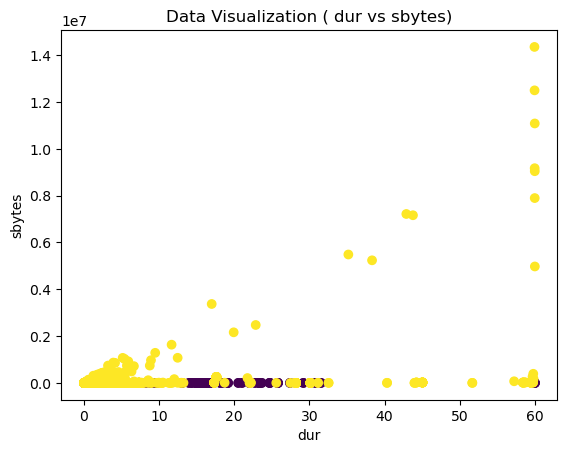

In [21]:
plt.scatter(x_vis["dur"], x_vis["sbytes"], c=y_vis)
plt.xlabel("dur")
plt.ylabel("sbytes")
plt.title("Data Visualization ( dur vs sbytes)")
plt.show()

## The data shows significant overlap between classess indicating it is not linearly seperable. Pereceptron may struggle while logictic regression should perform due to it probabilistic nature 

Text(0.5, 1.0, 'Better visualization')

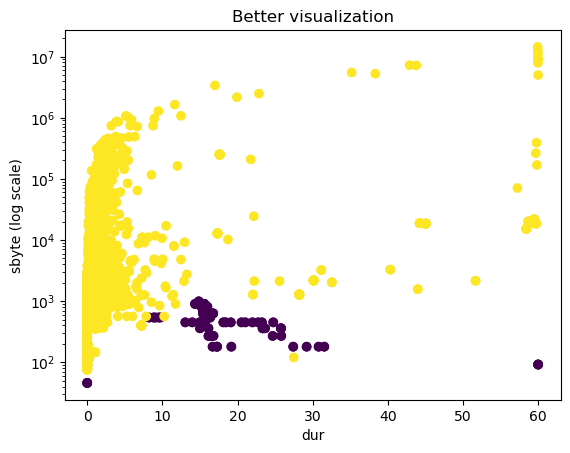

In [22]:
plt.figure ()
plt.scatter(x_vis["dur"] , x_vis [ "sbytes"], c=y_vis)
plt.yscale("log")
plt.xlabel("dur")
plt.ylabel("sbyte (log scale)")
plt.title("Better visualization")

In [26]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test =train_test_split ( 
    x_scaled, y, test_size=0.2, random_state=42
)

In [29]:
#Training Perceptron 
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
perceptron.fit(X_train, y_train)
y_pred_perc = perceptron.predict(X_test)

In [30]:
#Training Logistic Regression 
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train,y_train)
y_pred_log = log_reg.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score
print("Perceptron Accuracy", accuracy_score(y_test,y_pred_perc))
print("logictic regression Accuracy:", accuracy_score(y_test, y_pred_log))

Perceptron Accuracy 0.983
logictic regression Accuracy: 0.979


In [32]:
from sklearn.metrics import classification_report
print("Perceptron:")
print(classification_report(y_test,y_pred_perc))
print("Logistic Regression:")
print(classification_report(y_test,y_pred_log))

Perceptron:
              precision    recall  f1-score   support

           0       0.76      0.45      0.56        49
           1       0.99      1.00      0.99      1951

    accuracy                           0.98      2000
   macro avg       0.87      0.72      0.78      2000
weighted avg       0.98      0.98      0.98      2000

Logistic Regression:
              precision    recall  f1-score   support

           0       0.73      0.22      0.34        49
           1       0.98      1.00      0.99      1951

    accuracy                           0.98      2000
   macro avg       0.86      0.61      0.67      2000
weighted avg       0.97      0.98      0.97      2000



In [ ]:
## Altough both Models achieved high accuracy, 
# the dataset is highly imbalance
#Both Models favor the majority class ( attack)
# which led to poor detection of normal traffic
#This shows that accuracy alone is not reliable metric for 
#Evaluating Model Performance 

In [33]:
#Training Perceptron 
from sklearn.linear_model import Perceptron
perceptron = Perceptron(class_weight="balanced")
perceptron.fit(X_train, y_train)
y_pred_perc = perceptron.predict(X_test)

In [34]:
#Training Logistic Regression 
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(class_weight="balanced")
log_reg.fit(X_train,y_train)
y_pred_log = log_reg.predict(X_test)

In [35]:
from sklearn.metrics import classification_report
print(" Balanced Perceptron:")
print(classification_report(y_test,y_pred_perc))
print(" Balanced Logistic Regression:")
print(classification_report(y_test,y_pred_log))

 Balanced Perceptron:
              precision    recall  f1-score   support

           0       0.15      0.63      0.24        49
           1       0.99      0.91      0.95      1951

    accuracy                           0.90      2000
   macro avg       0.57      0.77      0.59      2000
weighted avg       0.97      0.90      0.93      2000

 Balanced Logistic Regression:
              precision    recall  f1-score   support

           0       0.12      0.78      0.21        49
           1       0.99      0.86      0.92      1951

    accuracy                           0.86      2000
   macro avg       0.56      0.82      0.56      2000
weighted avg       0.97      0.86      0.90      2000



In [36]:
## Visualizing Deision boundary 
x_vis =selected_df[["dur", "sbytes"]]
y_vis = selected_df["label"]

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler ()
x_vis_scaled = scaler.fit_transform(x_vis)


In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_vis_scaled, y_vis)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
import numpy as np

x_min, x_max = x_vis_scaled[:, 0].min() - 1, x_vis_scaled[:, 0].max() + 1
y_min, y_max = x_vis_scaled[:, 1].min() - 1, x_vis_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

In [43]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

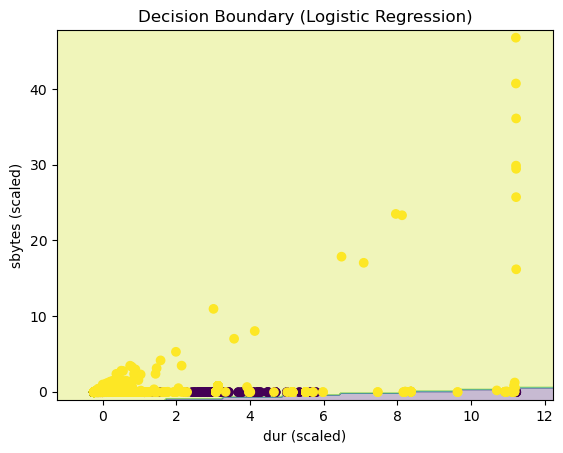

In [45]:
import matplotlib.pyplot as plt

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(x_vis_scaled[:, 0], x_vis_scaled[:, 1], c=y_vis)

plt.xlabel("dur (scaled)")
plt.ylabel("sbytes (scaled)")
plt.title("Decision Boundary (Logistic Regression)")

plt.show()

In [47]:
selected_df = df[["dur", "sbytes","dbytes","proto","sttl","dttl","label"]]
print(selected_df.head())

        dur  sbytes  dbytes proto  sttl  dttl  label
0  0.000011     496       0   udp   254     0      0
1  0.000008    1762       0   udp   254     0      0
2  0.000005    1068       0   udp   254     0      0
3  0.000006     900       0   udp   254     0      0
4  0.000010    2126       0   udp   254     0      0


In [48]:
#Encode proto so our udp and tcp becomes number 
selected_df = pd.get_dummies(selected_df, columns=["proto"])

In [49]:
#Seperate x and y 
x= selected_df.drop("label", axis=1)
y= selected_df["label"]

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler ()
x_scaled = scaler.fit_transform(x)


In [51]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test =train_test_split ( 
    x_scaled, y, test_size=0.2, random_state=42
)

In [52]:
#Training Logistic Regression 
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(class_weight="balanced")
log_reg.fit(X_train,y_train)
y_pred_log = log_reg.predict(X_test)

In [53]:
from sklearn.metrics import classification_report
print(" Balanced Logistic Regression:")
print(classification_report(y_test,y_pred_log))

 Balanced Logistic Regression:
              precision    recall  f1-score   support

           0       0.15      0.73      0.24        49
           1       0.99      0.89      0.94      1951

    accuracy                           0.89      2000
   macro avg       0.57      0.81      0.59      2000
weighted avg       0.97      0.89      0.92      2000



In [55]:
import pandas as pd

feature_names = selected_df.drop("label", axis=1).columns
coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

print(coef_df.sort_values(by="Coefficient", ascending=False))

        Feature  Coefficient
2        dbytes     5.948942
1        sbytes     4.761620
4          dttl     2.966088
123  proto_unas     1.959693
82   proto_ospf     0.935890
..          ...          ...
0           dur    -0.183758
46   proto_igmp    -0.296125
11    proto_arp    -0.311702
122   proto_udp    -0.649005
116   proto_tcp    -3.940042

[136 rows x 2 columns]
